In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [6]:
df = pd.read_csv('../Dataset/payroll_risk_dataset.csv')
df.head()


,emp_id,days_present,days_absent,leaves_taken,salary_prev,salary_curr,overtime_hours,risk_label
0,EMP1000,21,9,3,20860,21250,42,0
1,EMP1001,22,8,4,96820,98085,18,0
2,EMP1002,21,9,2,64131,75154,2,0
3,EMP1003,20,10,4,20769,18202,59,1
4,EMP1004,19,11,0,73707,88476,21,1


In [7]:
#Feature Engineering
#Attendance Feature
df['attendance_rate'] = df['days_present'] / (df['days_present'] +
df['days_absent'])


In [8]:
#Leave frequency feature
df['leave_ratio'] = df['leaves_taken'] / 30


In [9]:
#Salary change feature
df['salary_change'] = df['salary_curr'] - df['salary_prev']
df['salary_change_pct'] = df['salary_change'] / df['salary_prev']


In [10]:
#Overtime risk indicator
df['overtime_flag'] = np.where(df['overtime_hours'] > 40, 1, 0)

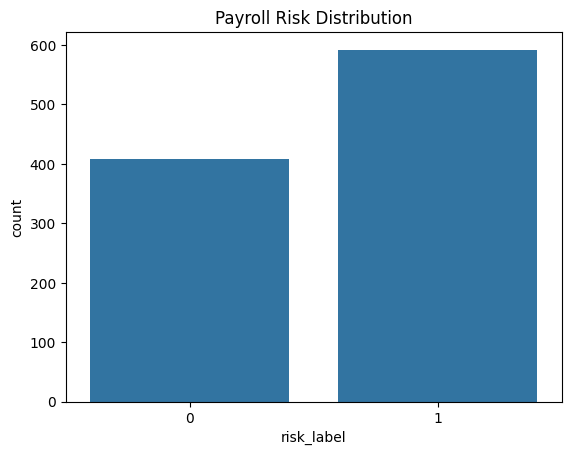

In [11]:
#EDA(Exploratory Data Analysis)
#Risk label distribution

sns.countplot(x='risk_label', data=df)
plt.title('Payroll Risk Distribution')
plt.show()

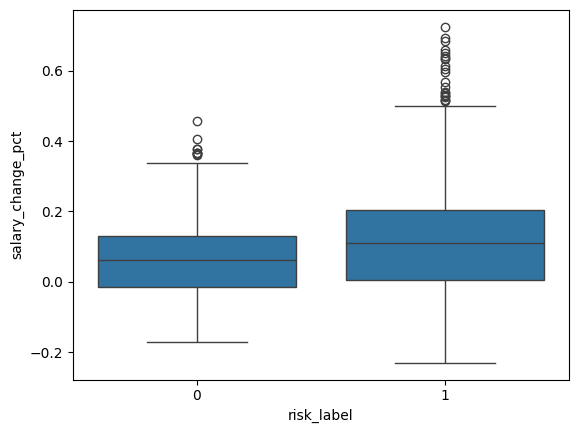

In [12]:
#Salary Change Percentage by Risk Label
sns.boxplot(x='risk_label', y='salary_change_pct', data=df)
plt.show()


In [13]:
#Data Preparation

X = df[['attendance_rate','leave_ratio','salary_change_pct','overtime_hours','overtime_flag']]
y = df['risk_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [14]:
#Logistic Regression(Model 1)
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


In [15]:
#Random Forest Classifier(Model 2)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [16]:
#SVM Classifier(Model 3)
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)


In [17]:
#MOdel Evaluation
def evaluate(y_true, y_pred):
    return {
'Accuracy': accuracy_score(y_true, y_pred),
'Precision': precision_score(y_true, y_pred),
'Recall': recall_score(y_true, y_pred),
'F1': f1_score(y_true, y_pred)
}


In [18]:
#Model Comparison table
results = pd.DataFrame([
evaluate(y_test, lr_pred),
evaluate(y_test, rf_pred),
evaluate(y_test, svm_pred)
], index=['Logistic Regression','Random Forest','SVM'])
4
results    

,Accuracy,Precision,Recall,F1
Logistic Regression,0.865,0.884956,0.877193,0.881057
Random Forest,0.950,0.972727,0.938596,0.955357
SVM,0.900,0.905172,0.921053,0.913043


mathematical justification ..

Chosen Model: Random Forest
Because payroll risk is non‑linear, involves interactions (attendance + salary + overtime), and RF minimizes generalization error."""


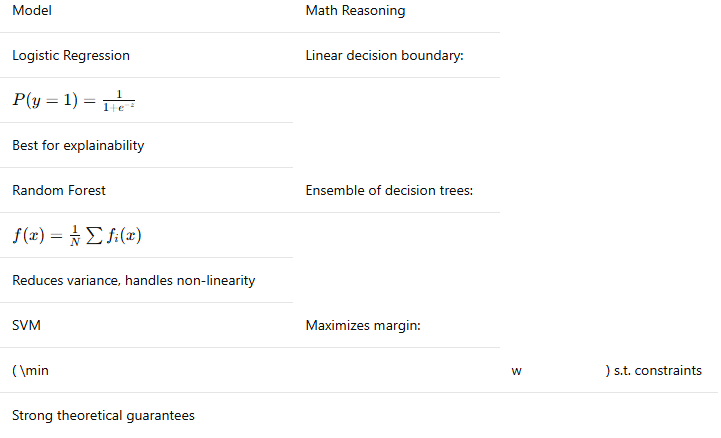

In [19]:
#Feature importance analysis  
importances = rf.feature_importances_
features = X.columns
feat_df = pd.DataFrame({'Feature':features,'Importance':importances})
feat_df.sort_values(by='Importance', ascending=False)


,Feature,Importance
0,attendance_rate,0.455816
3,overtime_hours,0.255995
2,salary_change_pct,0.153277
4,overtime_flag,0.109834
1,leave_ratio,0.025078


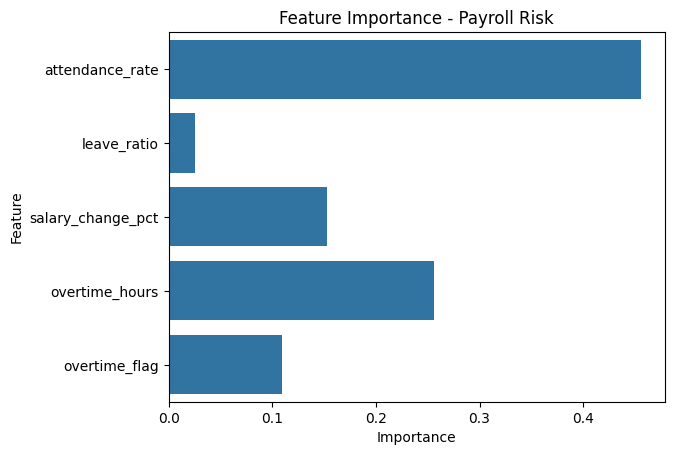

In [20]:
#Key Driver Analysis
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title('Feature Importance - Payroll Risk')
plt.show()